### Forecasting Human Emotions: Modeling Multiple Time Series with LSTMs and VAR

This notebook aims to address a challenging task: forecasting human emotions over time using time-series models. The dataset consists of **100 multiple time series** recordings, each capturing emotional dynamics over **1 to 10 minutes** at **0.1-second intervals**. Each time series is represented as a **600x7 matrix** (assuming a 1-minute length), where **600 timesteps** are recorded, and each timestep contains **7 features** representing different emotions as percentage values (e.g., `t=4.2s`, `[0.5, 0.2, 0.1, 0, 0.2, 0, 0]` means **50% happy**, **20% sad**, etc.).

The ultimate objective is to design a **machine learning model** capable of training on these time series to **forecast emotional states** for a **future time window**. In this notebook, we aim to determine the optimal number of lags to give the model and the ideal forecast length through experimentation. For ease of explanation, we will use **600 timesteps** to forecast the next **100 timesteps**, but these values will eventually be determined based on model performance.

### Objectives of the Notebook:

1. **Explore and Compare Modeling Techniques:**
   - We will test multiple **Long Short-Term Memory (LSTM)** architectures to handle the complex temporal relationships inherent in emotional data.
   - Additionally, we will explore models like **CNN-LSTM** and **ConvLSTM**, which may better capture local temporal features.
   - We will also compare these neural models to a more classical approach, the **Vector AutoRegression (VAR)** model, with both recursive and potentially direct multi-step forecasting.

2. **Design a Robust Experimentation Workflow:**
   - Split the dataset into **training** and **testing** subsets using non-overlapping segments of each time series (an **80-20 split**), ensuring there is no data leakage between sets.
   - Use a range of architectures, both with standard LSTMs and variations such as **Augmented LSTMs**, to evaluate their forecasting capability.
   - Experiment with **recursive prediction** and **direct multi-step prediction** for both LSTMs and VAR models to determine the best methodology for this task.

3. **Modeling and Tuning Variables:**
   - As mentioned, the number of timesteps to forecast (i.e., the forecast length) and the number of past observations (i.e., lags) to use as input features will be treated as hyperparameters. We will conduct experiments to determine which combination yields the best performance for emotional forecasting.
   - Initially, for demonstration purposes, we will use **600 timesteps** as the lookback window and forecast the next **100 timesteps**.

### Outline of the Notebook:

1. **Data Preprocessing:**
   - Prepare the data by splitting each time series into segments of **training** and **testing** sets, ensuring **no overlap** exists between them to prevent leakage.
   - Explore several data scaling methods to determine which yields the best results for time-series models.

2. **Exploration of LSTM Architectures:**
   - We will evaluate **multiple LSTM variations**, including:
     - **Basic LSTM models**
     - **Activated LSTM models** with ReLU activations
     - **Multistep LSTMs**
     - **Augmented LSTMs**, which concatenate additional features like recent timesteps to enhance context awareness
     - **CNN-LSTM** and **ConvLSTM** models to capture spatio-temporal dynamics

3. **VAR Modeling:**
   - Apply a **Vector AutoRegression (VAR)** model for comparison.
   - Implement both **recursive prediction** and potentially **direct multi-step forecasting** approaches to analyze their efficacy.

4. **Performance Metrics and Evaluation:**
   - Compare models using standard metrics such as **Mean Squared Error (MSE)** and evaluate on both training and testing sets.
   - Visualize **training and validation loss curves**, and plot **predicted vs. actual emotion vectors** for both training and test data.

5. **Results Analysis:**
   - Summarize the findings from testing different models.
   - Provide insights into which models and hyperparameter choices performed best and why.

### Expected Outcomes:

- A deeper understanding of which machine learning techniques work best for forecasting **multi-variate emotional time series**.
- Insights into the challenges and limitations of LSTMs, CNN-LSTMs, ConvLSTMs, and VAR models for this task.
- Identification of the optimal **number of lags** and **forecast window** length for this dataset.

In [43]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
import sys
import os
sys.path.append('/Users/arnav/Google Drive/Cornell/Coding Projects/emili_TimeSeriesPredictor') #going up several files until emili_TimeSeriesPredictor
from time_series_predictor.Data.emotionFeatureExtractor import emotionFeatureExtractor
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from statsmodels.tsa.stattools import adfuller, acf

### Exploring Statistical Properties of Emotion Data

In [44]:
# Loading data
extractor = emotionFeatureExtractor()
all_data = extractor.read_emotion_logs()
#obtains a train val and testing split
#should be such that all the data is saved in the same split random state

emotionMap = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Sadness', 'Surprise', 'Neutral']
#data imputation
#uses 'ewmainterp' method for resampling - determined it was the best method
resampled_data = [extractor.resample_data(file_data, 'ewmainterp') for file_data in all_data]


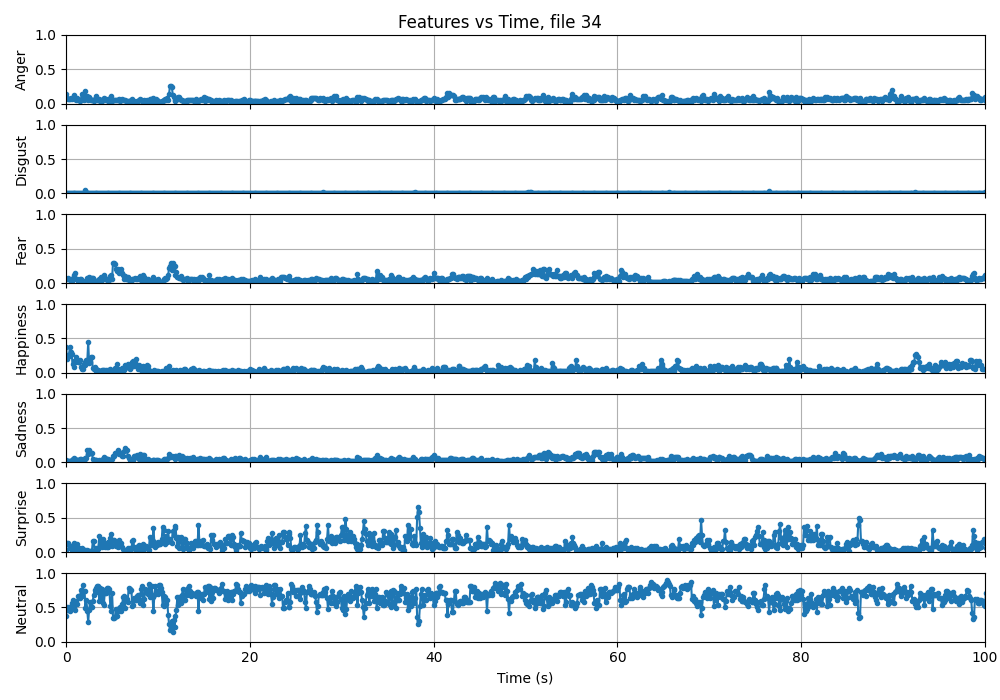

In [48]:

#plotting one of the timeseries
def plot_emotion_data(all_series, iFile):
    #input is a single timeseries of size (length,7)
    data = all_series[iFile]
    t = np.arange(0,0.1*np.shape(data)[0],0.1)
    nFeatures = np.shape(data)[1]

    fig, axes = plt.subplots(nFeatures, 1, figsize=(10, 1 * nFeatures), sharex=True, sharey = True)
    fig.suptitle(f'Features vs Time, file {iFile}')

    for iFeature in range(nFeatures):
        axes[iFeature].plot(t, data[:, iFeature], label='Data', marker = 'o', linestyle = '-', markersize=3)

    #label subplots
    for i in range(nFeatures):       
        axes[i].set_ylabel(f'{emotionMap[i]}')
        axes[i].grid(True)

    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)  # Adjust title position
    axes[-1].set_xlim(0, 100)
    axes[-1].set_ylim(0, 1)
    plt.show()

plot_emotion_data(resampled_data,34)

#### Stationarity testing

In [46]:
def analyze_stationarity_multivariate(all_series):
    """
    Apply stationarity tests to each feature in multivariate time series data.

    Parameters:
    - all_series: List of multivariate time series, each of shape (timesteps, features).

    Returns:
    - results: Dictionary with feature-wise results.
    """
    nFeatures = all_series[0].shape[1]
    results = {f'Feature_{i}': [] for i in range(nFeatures)}

    for series in all_series:
        for feature_idx in range(nFeatures):
            feature_data = series[:, feature_idx]
            adf_test = adfuller(feature_data, autolag='AIC')
            p_value = adf_test[1]
            results[f'Feature_{feature_idx}'].append(p_value)

    # Summarize results
    for feature, p_values in results.items():
        stationary_count = sum(p <= 0.05 for p in p_values)
        print(f"{feature}: {stationary_count}/{len(p_values)} series are stationary")
    
    return results

adf_results = analyze_stationarity_multivariate(resampled_data)

KeyboardInterrupt: 

#### Autocorrelation for the features

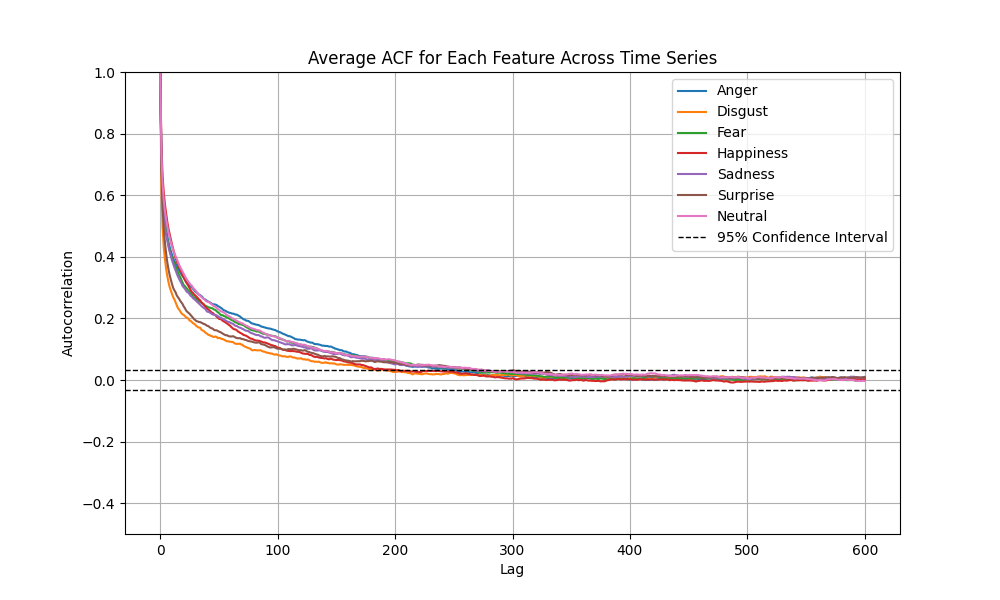

In [56]:
def plot_acf_multivariate(all_series, max_lag=600):
    """
    Plot autocorrelation for each feature in multivariate time series.

    Parameters:
    - all_series: List of multivariate time series, each of shape (timesteps, features).
    - max_lag: Maximum lag for autocorrelation.

    Returns:
    - None
    """
    n_features = all_series[0].shape[1]
    aggregated_acf = {f'Feature_{i}': np.zeros(max_lag + 1) for i in range(n_features)}

    nSeries = 0
    aggregated_length = 0

    for i,series in enumerate(all_series):
        if np.shape(series)[0] < 600:
            continue
        nSeries += 1
        for feature_idx in range(n_features):
            feature_data = series[:, feature_idx]
            acf_values = acf(feature_data, nlags=max_lag)
            aggregated_acf[f'Feature_{feature_idx}'] += acf_values
        aggregated_length += np.shape(series)[0] 

    # Average ACF across all series for each feature
    for feature in aggregated_acf:
        aggregated_acf[feature] /= nSeries

    conf_interval = 1.96 / np.sqrt(aggregated_length/nSeries) #95%

    # Plot averaged ACF for each feature
    plt.figure(figsize=(10, 6))
    for feature_idx, (feature, acf_values) in enumerate(aggregated_acf.items()):
        plt.plot(range(max_lag + 1), acf_values, label=f"{emotionMap[feature_idx]}",  markersize=3)
    # Add confidence interval dashed lines
        
    plt.axhline(y=conf_interval, color='black', linestyle='--', linewidth=1, label='95% Confidence Interval')
    plt.axhline(y=-conf_interval, color='black', linestyle='--', linewidth=1)

    plt.title("Average ACF for Each Feature Across Time Series")
    plt.xlabel("Lag")
    plt.ylabel("Autocorrelation")
    plt.ylim([-0.5,1])
    plt.legend()
    plt.grid(True)
    plt.show()

iFile = 12
plot_acf_multivariate(resampled_data)